In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def point_segment_distance(x, a, b):
    """
    Compute minimum Euclidean distance from point x to segment [a,b].
    (Same structure as the assignment's provided code listing.)
    """
    x = np.asarray(x, dtype=float)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    v = b - a
    w = x - a
    vv = np.dot(v, v)

    if vv == 0.0:
        return np.linalg.norm(x - a)

    t = np.dot(w, v) / vv
    t = np.clip(t, 0.0, 1.0)
    q = a + t * v
    return np.linalg.norm(x - q)

# ============================================================
# CORE: Penalty families phi(d)
# ============================================================
def phi_quadratic_band(d, R, **kwargs):
    return 0.5 * (R - d)**2 if d <= R else 0.0

def phi_quartic_band(d, R, **kwargs):
    return (R - d)**4 if d <= R else 0.0

def phi_log_barrier(d, R, eps=1e-2, **kwargs):
    # Strong repulsion; eps avoids singularity
    return np.log(R / (d + eps)) if d <= R else 0.0

def phi_inverse_distance(d, R, eps=1e-2, p=2, **kwargs):
    return 1.0 / ((d + eps)**p) if d <= R else 0.0

def phi_gaussian(d, R, sigma=0.8, truncate=True, **kwargs):
    val = np.exp(-(d**2) / (2.0 * sigma**2))
    if truncate and d > R:
        return 0.0
    return val

# ============================================================
# CORE: Goal attraction + wall costs (assignment Eq. style)
# ============================================================
def goal_cost(x, goal, k_goal=1.0):
    # Smooth quadratic attraction
    diff = x - goal
    return 0.5 * k_goal * np.dot(diff, diff)

def wall_cost(x, walls, phi_fn, R, w_wall=50.0, phi_kwargs=None):
    if phi_kwargs is None:
        phi_kwargs = {}
    total = 0.0
    for a, b in walls:
        d = point_segment_distance(x, a, b)
        total += w_wall * phi_fn(d, R=R, **phi_kwargs)
    return total

def total_cost(x, walls, goal, phi_fn, R, w_wall=50.0, k_goal=1.0, phi_kwargs=None):
    return goal_cost(x, goal, k_goal=k_goal) + wall_cost(x, walls, phi_fn, R, w_wall=w_wall, phi_kwargs=phi_kwargs)

# ============================================================
# CORE: Numerical gradient (finite differences)
# ============================================================
def numerical_grad(x, f, h=1e-3):
    g = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        xp = x.copy(); xp[i] += h
        xm = x.copy(); xm[i] -= h
        g[i] = (f(xp) - f(xm)) / (2.0 * h)
    return g

def gradient_descent_trajectory(
    walls, start, goal,
    phi_fn, R,
    w_wall=60.0, k_goal=1.0,
    step_size=0.1,
    max_step=0.05,
    max_iters=3000,
    goal_tol=0.2,
    phi_kwargs=None,
    grad_tol=1e-7,
    backtrack_beta=0.5,
    backtrack_max=20,
    stuck_jitter=0.01,
    stuck_patience=30,
    seed=0
):
    rng = np.random.default_rng(seed)
    start = np.asarray(start, dtype=float)
    goal  = np.asarray(goal, dtype=float)

    def f(z):
        return total_cost(z, walls, goal, phi_fn, R, w_wall=w_wall, k_goal=k_goal, phi_kwargs=phi_kwargs)

    x = start.copy()
    traj = [x.copy()]

    best_cost = f(x)
    no_improve = 0

    for _ in range(max_iters):
        # goal reached
        if np.linalg.norm(x - goal) <= goal_tol:
            break

        g = numerical_grad(x, f, h=1e-3)
        gnorm = np.linalg.norm(g)

        # local minimum / flat region
        if gnorm < grad_tol:
            # optional: tiny symmetry-break to escape symmetric trap
            if stuck_jitter > 0:
                x = x + stuck_jitter * rng.normal(size=2)
                traj.append(x.copy())
                continue
            else:
                break

        direction = -g / gnorm

        alpha = min(step_size, max_step)

        c0 = f(x)
        accepted = False
        for _bt in range(backtrack_max):
            x_new = x + alpha * direction
            c_new = f(x_new)
            if c_new <= c0:
                x = x_new
                accepted = True
                break
            alpha *= backtrack_beta

        if not accepted:
            if stuck_jitter > 0:
                x = x + stuck_jitter * rng.normal(size=2)
                traj.append(x.copy())
                continue
            else:
                break

        traj.append(x.copy())

        c_now = f(x)
        if c_now < best_cost - 1e-9:
            best_cost = c_now
            no_improve = 0
        else:
            no_improve += 1

        # If not improving for long, nudge slightly
        if stuck_jitter > 0 and no_improve >= stuck_patience:
            x = x + stuck_jitter * rng.normal(size=2)
            traj.append(x.copy())
            best_cost = f(x)
            no_improve = 0

    return np.array(traj)

# ============================================================
# visualization
# ============================================================
def evaluate_field(
    walls, goal,
    phi_fn, R,
    xmin, xmax, ymin, ymax,
    N=140,
    w_wall=60.0, k_goal=1.0,
    phi_kwargs=None
):
    xs = np.linspace(xmin, xmax, N)
    ys = np.linspace(ymin, ymax, N)
    X, Y = np.meshgrid(xs, ys)
    C = np.zeros_like(X, dtype=float)

    for i in range(N):
        for j in range(N):
            x = np.array([X[i, j], Y[i, j]])
            C[i, j] = total_cost(x, walls, goal, phi_fn, R, w_wall=w_wall, k_goal=k_goal, phi_kwargs=phi_kwargs)

    dCy, dCx = np.gradient(C, ys, xs)
    return X, Y, C, dCx, dCy

# ============================================================
# CORE: Plot helpers
# ============================================================
def plot_floor_plan(walls, start=None, goal=None, title="Floor Plan"):
    plt.figure(figsize=(6, 6))
    for a, b in walls:
        plt.plot([a[0], b[0]], [a[1], b[1]], "k-", linewidth=2)
    if start is not None:
        plt.plot(start[0], start[1], "go", markersize=8, label="Start")
    if goal is not None:
        plt.plot(goal[0], goal[1], "ro", markersize=8, label="Goal")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.show()

def plot_result(walls, start, goal, X, Y, C, dCx, dCy, traj, title=""):
    plt.figure(figsize=(8, 7))
    plt.contourf(X, Y, C, levels=40, cmap="viridis")
    plt.colorbar(label="Total cost")

    skip = (slice(None, None, 6), slice(None, None, 6))
    plt.quiver(X[skip], Y[skip], -dCx[skip], -dCy[skip], color="white", alpha=0.6)

    for a, b in walls:
        plt.plot([a[0], b[0]], [a[1], b[1]], "k-", linewidth=2)

    if len(traj) >= 2:
        plt.plot(traj[:, 0], traj[:, 1], "r-", linewidth=2, label="Trajectory")
    else:
        plt.plot(traj[:, 0], traj[:, 1], "rx", markersize=10, label="Trajectory (stuck)")

    plt.plot(start[0], start[1], "go", markersize=8, label="Start")
    plt.plot(goal[0], goal[1], "ro", markersize=8, label="Goal")

    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend()
    plt.show()

def load_floor_plan(name="baseline"):
    if name == "baseline":
        walls = [
            ([-5, -5], [ 5, -5]),
            ([ 5, -5], [ 5,  5]),
            ([ 5,  5], [-5,  5]),
            ([-5,  5], [-5, -5]),
            ([-1, -5], [-1,  2]),
            ([-1,  2], [ 3,  2]),
            ([ 3,  2], [ 3, -2]),
        ]
        start = [-4.0, -4.0]
        goal  = [ 4.0,  4.0]

    elif name == "zigzag":
        walls = [
            ([-6, -4], [ 6, -4]),
            ([ 6, -4], [ 6,  4]),
            ([ 6,  4], [-6,  4]),
            ([-6,  4], [-6, -4]),
            ([-4, -3], [-1, -3]),
            ([-1, -3], [-1,  0]),
            ([-1,  0], [ 2,  0]),
            ([ 2,  0], [ 2,  3]),
            ([ 2,  3], [ 5,  3]),
        ]
        start = [-5.0, -3.5]
        goal  = [ 5.0,  3.5]

    elif name == "deadend":
        walls = [
            ([-6, -6], [ 6, -6]),
            ([ 6, -6], [ 6,  6]),
            ([ 6,  6], [-6,  6]),
            ([-6,  6], [-6, -6]),
            ([-2, -6], [-2,  2]),
            ([-2,  2], [ 2,  2]),
            ([ 2,  2], [ 2, -2]),
            ([ 2, -2], [-4, -2]),
            ([-4, -2], [-4,  4]),
        ]
        start = [ 0.0, -5.0]
        goal  = [ 5.0,  5.0]

    elif name == "symmetric":
        walls = [
            ([-6, -6], [ 6, -6]),
            ([ 6, -6], [ 6,  6]),
            ([ 6,  6], [-6,  6]),
            ([-6,  6], [-6, -6]),
            ([-2, -2], [-2,  2]),
            ([ 2, -2], [ 2,  2]),
            ([-2,  2], [ 2,  2]),
        ]
        start = [ 0.0, -5.0]
        goal  = [ 0.0,  5.0]
    else:
        raise ValueError(f"Unknown floor plan: {name}")

    walls = [(np.array(a, dtype=float), np.array(b, dtype=float)) for a, b in walls]
    start = np.array(start, dtype=float)
    goal  = np.array(goal, dtype=float)
    return walls, start, goal

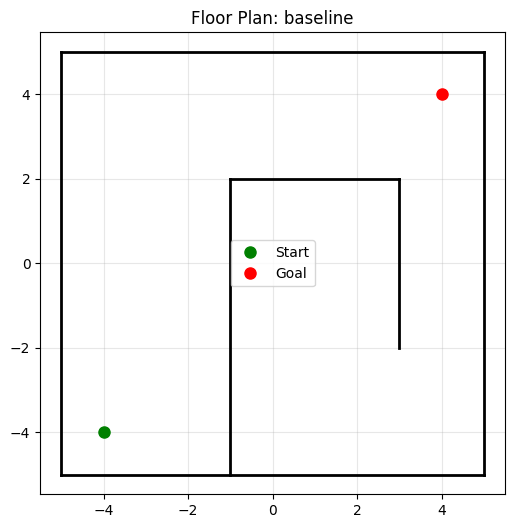

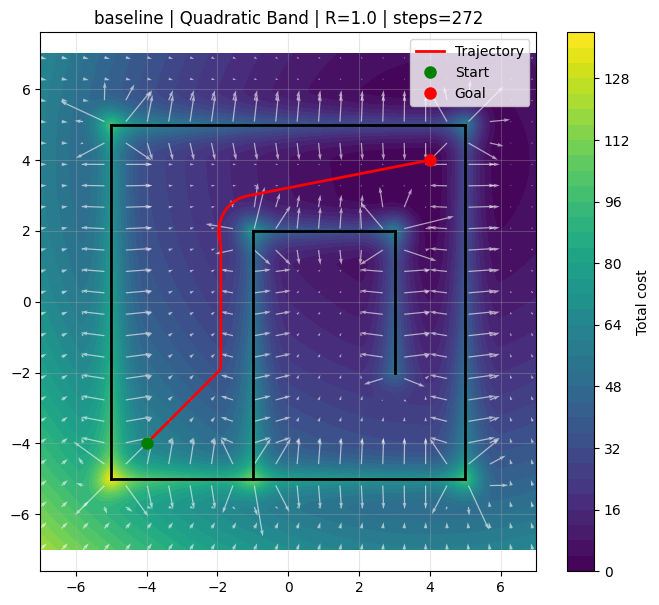

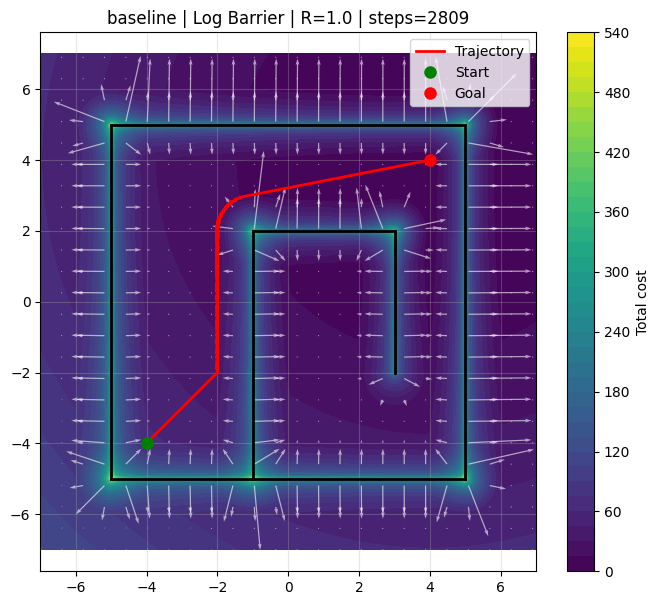

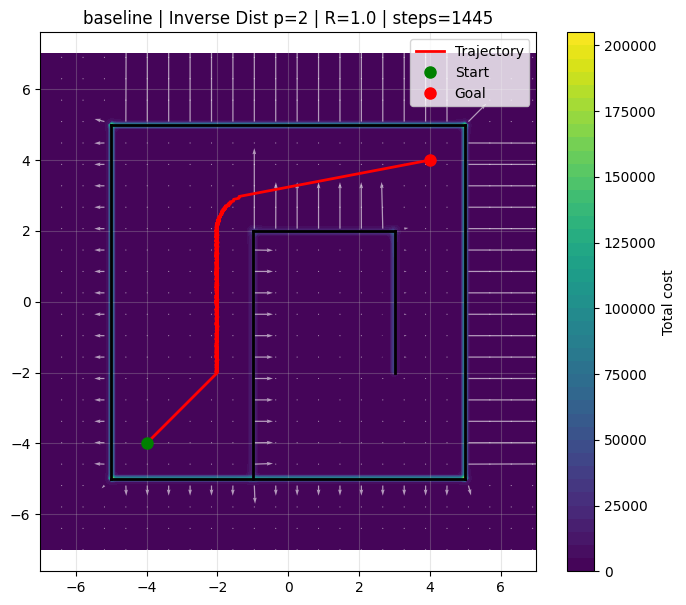

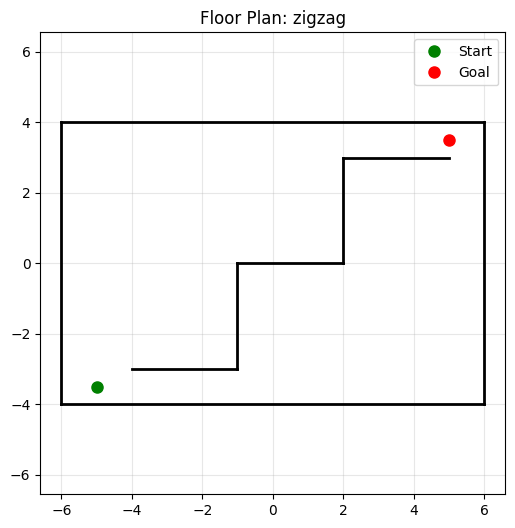

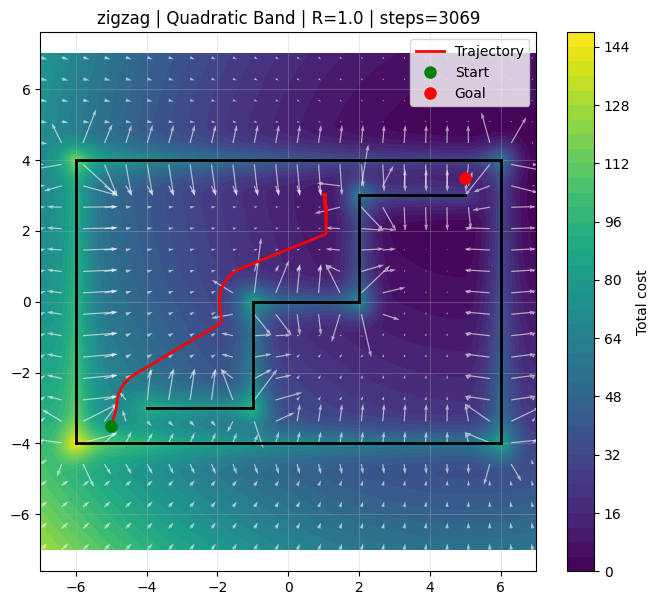

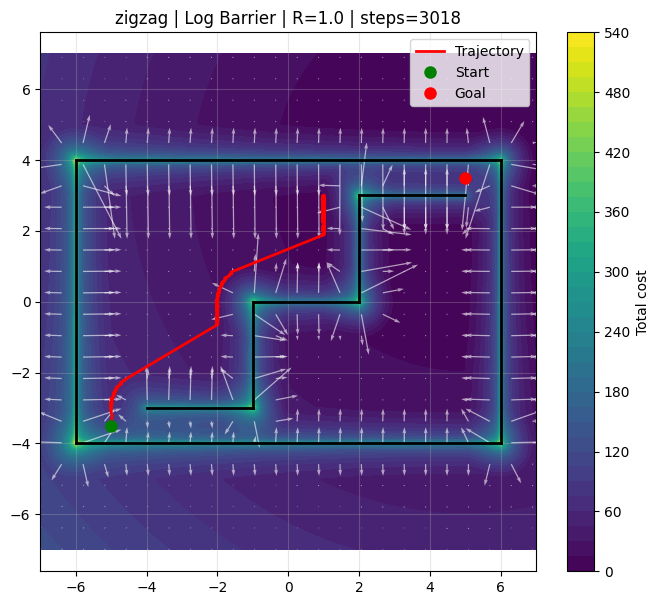

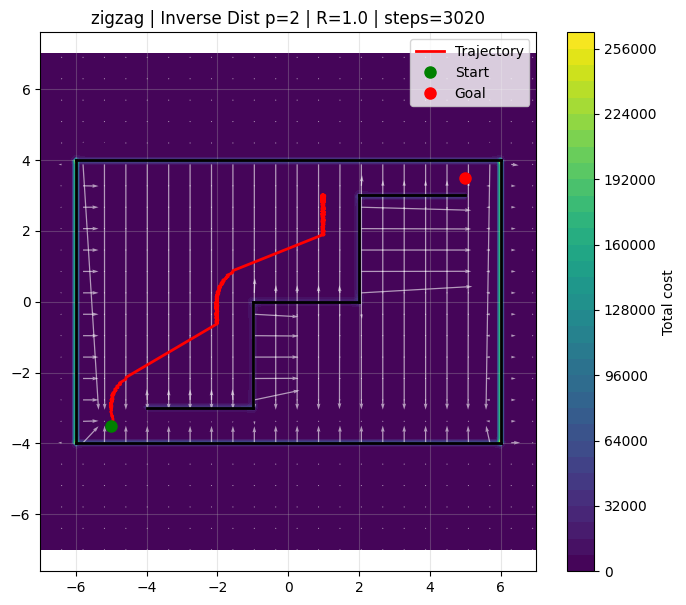

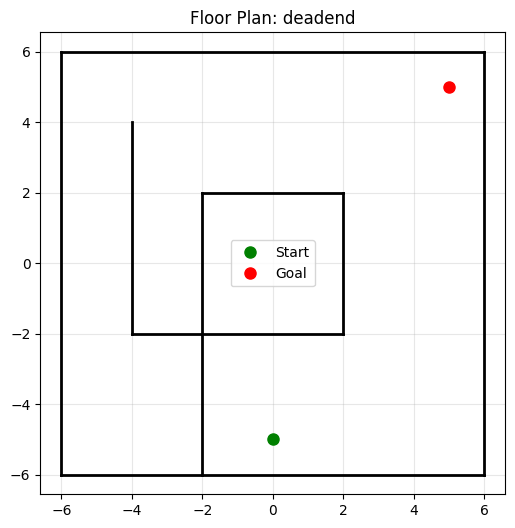

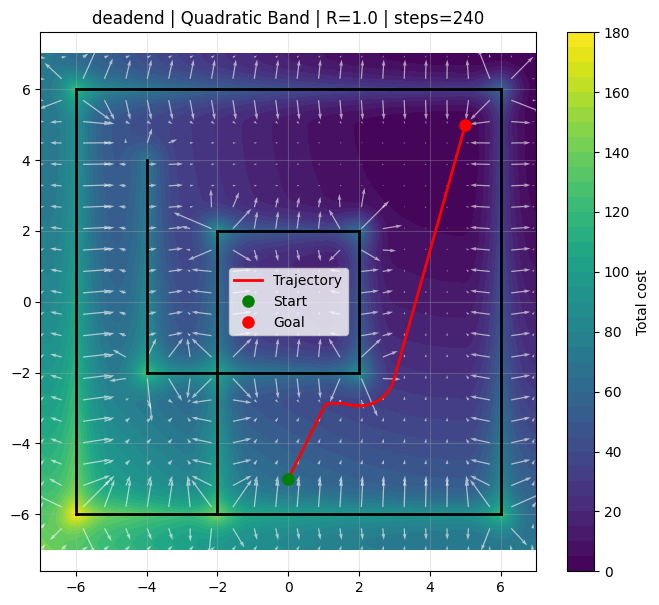

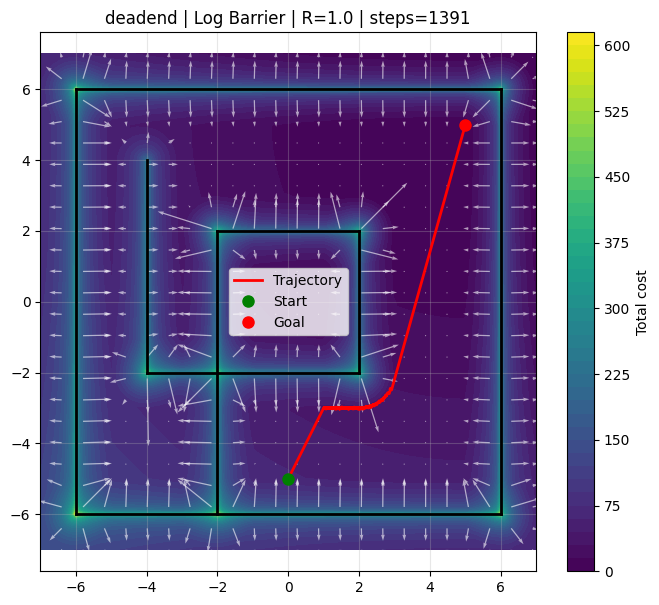

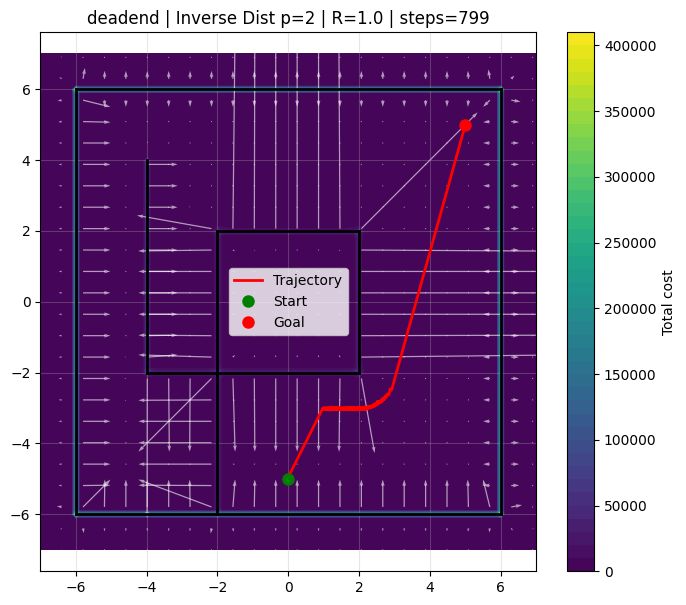

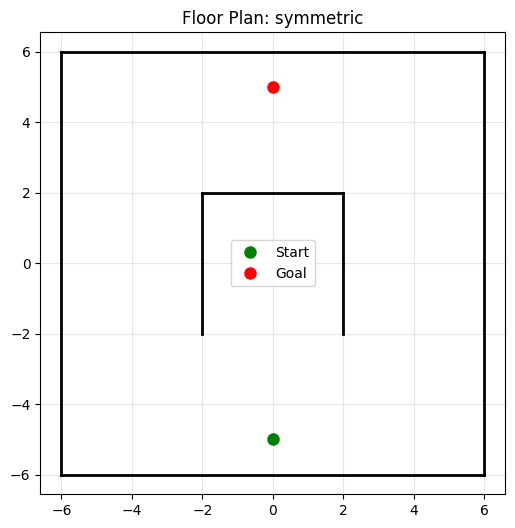

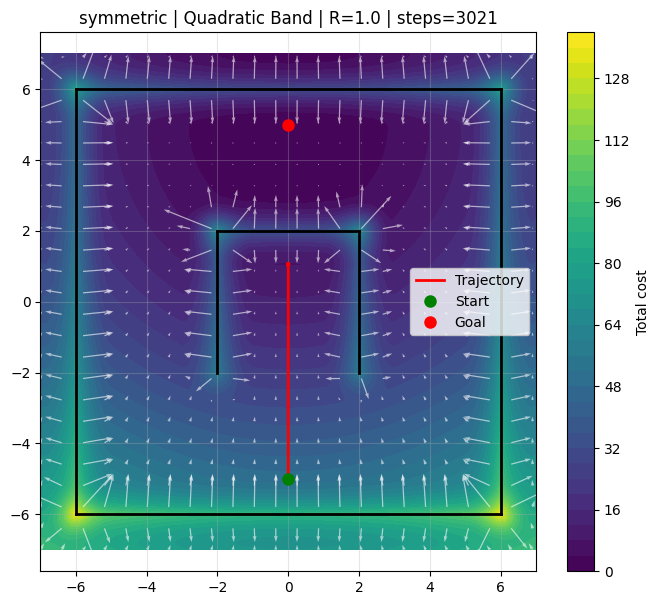

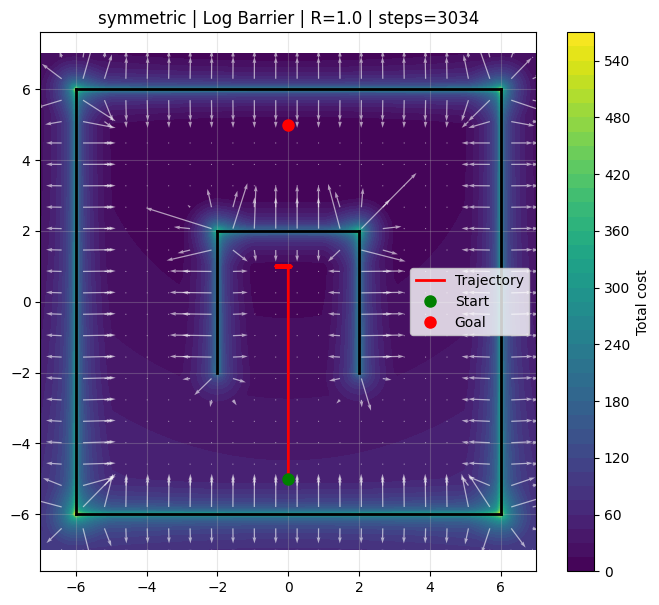

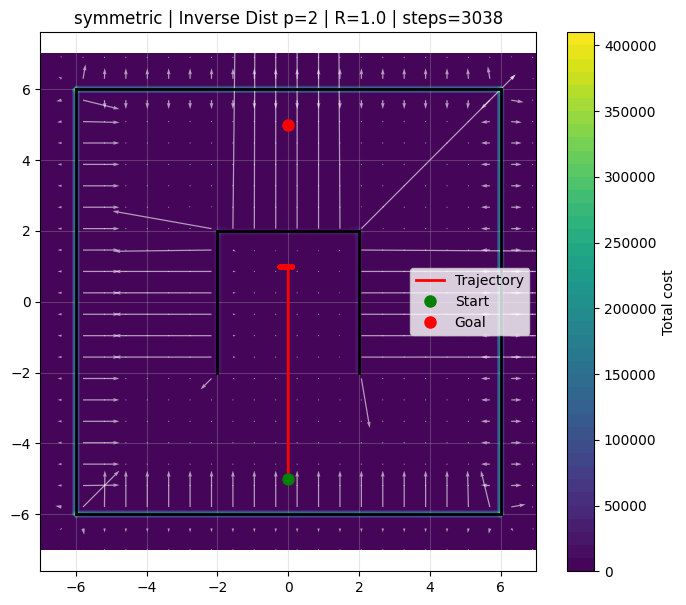

In [ ]:
plans = ["baseline", "zigzag", "deadend", "symmetric"]

configs = [
    ("Quadratic Band", phi_quadratic_band, 1.0, {}),
    ("Log Barrier", phi_log_barrier, 1.0, {"eps": 1e-2}),
    ("Inverse Dist p=2", phi_inverse_distance, 1.0, {"eps": 1e-2, "p": 2}),
]

for plan_name in plans:
    walls, start, goal = load_floor_plan(plan_name)
    plot_floor_plan(walls, start, goal, title=f"Floor Plan: {plan_name}")

    for name, phi_fn, R, kwargs in configs:
        traj = gradient_descent_trajectory(
            walls, start, goal,
            phi_fn=phi_fn, R=R,
            w_wall=60.0, k_goal=1.0,
            step_size=0.12,
            max_step=0.05,
            max_iters=3000,
            goal_tol=0.2,
            phi_kwargs=kwargs,
            stuck_jitter=0.01,
            seed=1
        )

        X, Y, C, dCx, dCy = evaluate_field(
            walls, goal,
            phi_fn=phi_fn, R=R,
            xmin=-7, xmax=7, ymin=-7, ymax=7,
            N=140,
            w_wall=60.0, k_goal=1.0,
            phi_kwargs=kwargs
        )

        plot_result(walls, start, goal, X, Y, C, dCx, dCy, traj,
                    title=f"{plan_name} | {name} | R={R} | steps={len(traj)}")

## 2.6 Analysis

### 1. How does wall thickness or influence radius affect the resulting path?

The wall thickness or influence radius R determines how far from a wall the penalty field extends and therefore how early the wall begins to influence motion.

**Small influence radius (thin wall effect)**

*   Repulsion activates only when the agent is very close to the wall.
*   The path tends to be more direct and closer to walls.
*   Clearance from obstacles is low.
*   There is a higher risk of “grazing” or even crossing walls if the step size is large or the gradient is weak.
*   Motion is smoother in open areas because fewer forces act on the agent.

**Observed behavior:**

In baseline scenarios, small R produced tight turns around corners and paths hugging walls.

**Large influence radius (thick wall effect)**

*   Repulsion begins far from the wall.
*   The agent keeps a larger safety distance from obstacles.
*   Paths become wider and more curved.
*   Narrow passages may become difficult or impossible to traverse because overlapping influence zones create a high-cost region across the corridor.
*   Can introduce additional local minima.

**Observed behavior:**

In zigzag corridors, large R caused the agent to slow down, oscillate, or fail to progress because both sides of the corridor exert strong repulsion.

### 2. What happens near corners or narrow corridors?

**Near Corners**

Corners combine the influence of multiple walls simultaneously. Since each wall generates a penalty field, these fields overlap near the corner region. As a result, the gradient of the combined cost function changes direction rapidly.

Instead of following the geometric shape of the corridor, the agent begins turning earlier than expected. This produces smooth, curved trajectories that “round” the corner rather than making a sharp turn.

When strong penalty functions such as the log barrier or inverse-distance repulsion are used, the gradients near the corner can become very steep. This may cause abrupt direction changes or unstable motion.

**Observed behavior:**

In the baseline floor plan, the trajectory curved outward before entering the interior corridor, indicating that the combined wall repulsion influenced motion well before the actual corner was reached.

**In Narrow Corridors**

Narrow corridors create opposing repulsive forces from walls on both sides. Because the agent moves according to the local gradient of the total cost, these competing forces can significantly affect motion.

**Several characteristic behaviors may occur:**

**Oscillation:**

The agent may move back and forth between the corridor walls as each wall pushes it away. This effect is especially pronounced with steep penalty functions, which generate strong gradients near the walls.

**Slow Progress:**

The repulsive forces from opposite walls partially cancel each other, reducing the net gradient toward the goal. As a result, forward motion becomes slow.

**Failure to Pass Through:**

If the influence radius is large relative to the corridor width, the penalty fields from both walls can overlap completely. In this case, the entire corridor becomes a high-cost region, leaving no clear downhill direction toward the goal. The agent may stall or fail to enter the corridor at all.

### 3. Does the method ever get stuck? Why or why not?

Yes — the method can get stuck.

This occurs because motion is based solely on local gradients of the cost function.

**Local minima**

A local minimum is a point where:

∇C(x)≈0

but the goal has not been reached.

At this point, gradient descent stops because no downhill direction exists.